In [12]:
import numpy as np
import pandas as pd
from sklearn import metrics
from openpyxl import load_workbook
from sklearn.tree import export_graphviz
from sklearn.ensemble import RandomForestRegressor
from netCDF4 import Dataset
import matplotlib.pyplot as plt
import multiprocessing
import os
import time
import gloce as gc
from osgeo import gdal
from osgeo import gdalconst
from mpl_toolkits.basemap import Basemap
from glob import glob
from math import ceil
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde
#return im_data, im_width, im_height, im_geotrans, im_proj
def read_img(filename):
    dt = gdal.Open(filename)
    im_width = dt.RasterXSize
    im_height = dt.RasterYSize
    im_bands = dt.RasterCount
    im_geotrans = dt.GetGeoTransform()
    im_proj = dt.GetProjection()
    im_data = dt.ReadAsArray(0,0,im_width,im_height)
    return im_data, im_width, im_height, im_geotrans, im_proj
def write_img(filename, im_proj, im_geotrans, im_data):
    if 'int8' in im_data.dtype.name:
        datatype = gdal.GDT_Byte
    elif 'int16' in im_data.dtype.name:
        datatype = gdal.GDT_UInt16
    else:
        datatype = gdal.GDT_Float32
    if len(im_data.shape) == 3:
        im_bands, im_height, im_width = im_data.shape
    else:
        im_bands, (im_height, im_width) = 1, im_data.shape
    driver = gdal.GetDriverByName("GTiff")
    dataset = driver.Create(filename, im_width, im_height, im_bands, datatype)
    dataset.SetGeoTransform(im_geotrans)
    dataset.SetProjection(im_proj)
    if im_bands == 1:
        dataset.GetRasterBand(1).WriteArray(im_data)
    else:
        for i in range(im_bands):
            dataset.GetRasterBand(i + 1).WriteArray(im_data[i])
spei_path='//weili/User2/mxsun/CESS_230818/SPEI_highRes/'
sm_path='//weili/User2/mxsun/CESS_230818/SPEI_highRes/RF/'
soil_path='//weili/User2/mxsun/CESS_230818/SPEI_highRes/RF/'
drv_path='//weili/User2/mxsun/CESS_230818/Pattern_drive/'
buffer_path='//weili/User2/mxsun/CESS_230818/revise_test/'

# loc_mask_prepare

In [102]:
loc_site=read_img(spei_path+"Elephant_locs_001_240820_update.tif")[0]
loc_site[loc_site<0]=0
np.nanmin(loc_site),np.nanmax(loc_site)

(0.0, 1.0)

In [103]:
#site buffers 1-5km
from scipy.ndimage import binary_dilation
def apply_buffer(loc_site, max_radius=5):
    # 存储结果的矩阵，避免修改原矩阵
    result = loc_site.copy()
    # 生成3x3结构元素
    structure = np.ones((3, 3), dtype=bool)
    # 对1值的周围区域应用buffer
    for radius in range(1, max_radius + 1):
        # 使用binary_dilation进行扩展
        result = binary_dilation(result, structure=structure).astype(int)
    return result

for i in range(10):
    loc_buffer=apply_buffer(loc_site,max_radius=i+1)
    write_img(buffer_path+'Elephant_locs_buffer_{}km_241203.tif'.format(i+1),dt[4],dt[3],loc_buffer)

In [26]:
dt=read_img(spei_path+'SPEI_deaa001_240504.tif')
loc_buf=read_img(buffer_path+'Elephant_locs_buffer_1km_241203.tif')[0]
loc_buf.shape

(6500, 7900)

# data prepare

In [28]:
DEAA=read_img(spei_path+'SPEI_deaa001_240504.tif')[0]
DAA=read_img(spei_path+'SPEI_daa001_240504.tif')[0]
DEAA[DEAA==0]=np.nan
DAA[DAA==0]=np.nan

In [29]:
dem=read_img(spei_path+'gtopoDEM_afr_001.tif')[0]
slope=read_img(spei_path+'gtopoSlope_afr_001.tif')[0]
print('dem',dem.min(),dem.max())
print('slope',slope.min(),slope.max())
dem=dem.astype(np.float32)
dem[dem==-9999]=np.nan
slope[slope==0]=np.nan

hfp = read_img(spei_path+'hfp2018_Afirca_001_230525.tif')[0]
hfp[hfp<=15]=1
hfp[hfp>1]=np.nan
mask=hfp#*forest_mask
mask[~np.isnan(mask)]=1
np.nanmin(mask),np.nanmax(mask)

dem -9999 5438
slope -3.402823e+38 79.12291


(1.0, 1.0)

# paired method

## consider surround grid

In [287]:
"""
2024/12/03
edit by Minxuan Sun
test the changes in vegetation by elephants, with elephant local sites buffer
randomly select from the same area from the area without elepahnts
"""
def random_difference_a(s,dist1, dist2, res_arr):
    #s: window size
    #dist1: mask area with elephants
    #dist2: mask area without elephants
    #res_arr: resistance+dem_slopw (3,rows,cols)
    diff_arr=np.zeros((260,316))
    for i in range(1,259):#后面有搜索周围格点，确保不超出边界
        for j in range(1,315):
            bloc_dist1=dist1[i*s:(i+1)*s,j*s:(j+1)*s]#mask DEAA region
            bloc_dist2=dist2[i*s:(i+1)*s,j*s:(j+1)*s]#mask DAA region
            #print(bloc_dist2.shape)
            res_dist=res_arr[:,i*s:(i+1)*s,j*s:(j+1)*s]

            res_mask1=np.multiply(bloc_dist1,res_dist)#variable value of DEAA region
            res_mask2=np.multiply(bloc_dist2,res_dist)#variable value of DAA region
            res_mask1=res_mask1.reshape(3,-1)
            res_mask2=res_mask2.reshape(3,-1)
            res_mask1 = res_mask1[:, ~np.isnan(res_mask1[0])]
            res_mask2 = res_mask2[:, ~np.isnan(res_mask2[0])]
            if res_mask1.size == 0:
                continue  # 如果是空数组，跳过该步骤
            
            control_dif1=np.nanmean(res_mask1[1])-np.nanmean(res_mask2[1])#dem difference
            control_dif2=np.nanmean(res_mask1[2])-np.nanmean(res_mask2[2])#slope difference
            
            weight1=np.count_nonzero(~np.isnan(res_mask1[0]))/625
            weight2=np.count_nonzero(~np.isnan(res_mask2[0]))/625
            ##############################当前0.25°×0.25°格点###########################################
            if abs(weight1-weight2)<0.1:
                if  weight2>0 and abs(control_dif1)<200 and abs(control_dif2)<10:
                    diff_arr[i,j]=np.nanmean(res_mask1[0])-np.nanmean(res_mask2[0])
            #---------当前格点的elephant和non-elephant面积差距>10%,对较大的一方random 10次取均值--------------
            else:
                if weight2>weight1:#如果无象区更大，直接random
                    #larger,smaller=res_mask2,res_mask1
                    #larger_matrix='res_mask2'
                    #抽样，取均值
                    num_samples=np.count_nonzero(~np.isnan(res_mask1[0]))
                    num_trials=10
                    mean_value=[]
                    for _ in range(num_trials):#_是一个惯用的变量名，是一个占位符，用于指代循环次数，但我们不需要实际使用这个循环变量的值
                        # 从较大的矩阵中随机选取num_samples个值（放回抽样）
                        #print(larger.shape)
                        select_columns = np.random.choice(res_mask2.shape[1], size=num_samples, replace=True)
                        #print(len(select_columns))
                        sampled_values = res_mask2[:,select_columns]
                        large_mean=np.nanmean(sampled_values,axis=1)#求每行均值
                        small_mean=np.nanmean(res_mask1,axis=1)
                        dem_dif=np.abs(large_mean[1]-small_mean[1])
                        slope_dif=np.abs(large_mean[2]-small_mean[2])
                        if dem_dif<200 and slope_dif<10:
                            diff_arr[i,j] = small_mean[0]-large_mean[0]
            ##############################搜索周围0.25°×0.25°格点###########################################
            if diff_arr[i,j]==0:#如果还没组队成功，再搜索周围格点
                bloc_dist_a=[]
                res_dist_a=[]
                res_mask_pool=[]
                weight_pool=[]
                offsets= [(-1, 0),(0, -1),(-1, -1),(1, 0),(0, 1),(1, 1),(-1, 1),(1, -1)]
                dif_w=[]
                for dx, dy in offsets:
                    bloc_dist2a = dist2[(i+dx)*s:((i+dx)+1)*s, (j+dy)*s:((j+dy)+1)*s]
                    res_mask2a = np.multiply(bloc_dist2a, res_dist)
                    res_mask2a=res_mask2a.reshape(3,-1)
                    res_mask2a = res_mask2a[:, ~np.isnan(res_mask2a[0])]
                    if res_mask2a.size == 0:
                        continue  # 如果是空数组，跳过该步骤
                    dem_dif=np.nanmean(res_mask1[1])-np.nanmean(res_mask2a[1])#dem difference
                    slope_dif=np.nanmean(res_mask1[2])-np.nanmean(res_mask2a[2])#slope difference
                    weight2a=np.count_nonzero(~np.isnan(res_mask2a[0]))/625
                    dif_w.append(weight1-weight2a)
                    if abs(weight1-weight2a)<0.1:
                        if  weight2a>0 and abs(dem_dif)<200 and abs(slope_dif)<10:
                            diff_arr[i,j] = np.nanmean(res_mask1[0])-np.nanmean(res_mask2a[0])
                if diff_arr[i,j]==0 and len(dif_w)>0:#如果还没组队成果，再从周围格点中挑选无象区比有象区面积最大的格点，做random
                    key=np.argmin(dif_w)#dif_w<0表示weight2a>weight1
                    dxx=offsets[key][0]
                    dyy=offsets[key][1]
                    bloc_dist2b=dist2[(i+dxx)*s:((i+dxx)+1)*s, (j+dyy)*s:((j+dyy)+1)*s]
                    res_mask2b=np.multiply(bloc_dist2b,res_dist)
                    res_mask2b=res_mask2a.reshape(3,-1)
                    res_mask2b = res_mask2a[:, ~np.isnan(res_mask2a[0])]
                    if res_mask2b.size == 0:
                        continue  # 如果是空数组，跳过该步骤
                    dem_dif=np.nanmean(res_mask1[1])-np.nanmean(res_mask2b[1])#dem difference
                    slope_dif=np.nanmean(res_mask1[2])-np.nanmean(res_mask2b[2])#slope difference
                    num_samples=np.count_nonzero(~np.isnan(res_mask1[0]))
                    num_trials=10
                    for _ in range(num_trials):#_是一个惯用的变量名，是一个占位符，用于指代循环次数，但我们不需要实际使用这个循环变量的值
                        # 从较大的矩阵中随机选取num_samples个值（放回抽样）
                        #print(larger.shape)
                        select_columns = np.random.choice(res_mask2b.shape[1], size=num_samples, replace=True)
                        #print(len(select_columns))
                        sampled_values = res_mask2b[:,select_columns]
                        large_mean=np.nanmean(sampled_values,axis=1)#求每行均值
                        small_mean=np.nanmean(res_mask1,axis=1)
                        dem_dif=np.abs(large_mean[1]-small_mean[1])
                        slope_dif=np.abs(large_mean[2]-small_mean[2])
                        if dem_dif<200 and slope_dif<10:
                            diff_arr[i,j] = small_mean[0]-large_mean[0]
    diff_arr[diff_arr==0]=np.nan
    return diff_arr

## direct random

In [114]:
"""
2024/12/03
edit by Minxuan Sun
test the changes in vegetation by elephants, with elephant local sites buffer
randomly select from the same area from the area without elepahnts
"""
def random_difference_a(s,dist1, dist2, res_arr):
    #s: window size
    #dist1: mask area with elephants
    #dist2: mask area without elephants
    #res_arr: resistance+dem_slopw (3,rows,cols)
    diff_arr=np.zeros((260,316))
    for i in range(260):
        for j in range(316):
            bloc_dist1=dist1[i*s:(i+1)*s,j*s:(j+1)*s]#mask DEAA region
            bloc_dist2=dist2[i*s:(i+1)*s,j*s:(j+1)*s]#mask DAA region
            res_dist=res_arr[:,i*s:(i+1)*s,j*s:(j+1)*s]

            res_mask1=np.multiply(bloc_dist1,res_dist)#variable value of DEAA region
            res_mask2=np.multiply(bloc_dist2,res_dist)#variable value of DAA region
            res_mask1=res_mask1.reshape(3,-1)
            res_mask2=res_mask2.reshape(3,-1)
            res_mask1 = res_mask1[:, ~np.isnan(res_mask1[0])]
            res_mask2 = res_mask2[:, ~np.isnan(res_mask2[0])]
            
            control_dif1=np.nanmean(res_mask1[1])-np.nanmean(res_mask2[1])#dem difference
            control_dif2=np.nanmean(res_mask1[2])-np.nanmean(res_mask2[2])#slope difference
            
            weight1=np.count_nonzero(~np.isnan(res_mask1[0]))/625
            weight2=np.count_nonzero(~np.isnan(res_mask2[0]))/625
            if abs(weight1-weight2)<0.1:
                if  weight2>0 and abs(control_dif1)<200 and abs(control_dif2)<10:
                    diff_arr[i,j]=np.nanmean(res_mask1[0])-np.nanmean(res_mask2[0])
            #---------当前格点的elephant和non-elephant面积差距>10%,对较大的一方random 10次取均值--------------
            else:
                if weight2>weight1:#如果无象区更大，直接random
                    #larger,smaller=res_mask2,res_mask1
                    #larger_matrix='res_mask2'
                    #抽样，取均值
                    num_samples=np.count_nonzero(~np.isnan(res_mask1[0]))
                    num_trials=10
                    mean_value=[]
                    for _ in range(num_trials):#_是一个惯用的变量名，是一个占位符，用于指代循环次数，但我们不需要实际使用这个循环变量的值
                        # 从较大的矩阵中随机选取num_samples个值（放回抽样）
                        #print(larger.shape)
                        select_columns = np.random.choice(res_mask2.shape[1], size=num_samples, replace=True)
                        #print(len(select_columns))
                        sampled_values = res_mask2[:,select_columns]
                        large_mean=np.nanmean(sampled_values,axis=1)#求每行均值
                        small_mean=np.nanmean(res_mask1,axis=1)
                        dem_dif=np.abs(large_mean[1]-small_mean[1])
                        slope_dif=np.abs(large_mean[2]-small_mean[2])
                        if dem_dif<200 and slope_dif<10:
                            diff_arr[i,j] = small_mean[0]-large_mean[0]
    diff_arr[diff_arr==0]=np.nan
    return diff_arr

# forest sructure differ

In [288]:
treeH = read_img(spei_path+'African_th2019_001_230525.tif')[0]
tc_planet = read_img(spei_path+'Africa_tc2019_mosaic_001_fillNaN_231215.tif')[0]
treeH[treeH==0]=np.nan
tc_planet=tc_planet.astype(np.float32)
tc_planet[tc_planet==0]=np.nan
tc_planet[tc_planet>100]=np.nan

In [289]:
th_res=np.stack([treeH,dem,slope])
tc_res=np.stack([tc_planet,dem,slope])
res_pool=[th_res,tc_res] #protect need conver to fraction
res_name=['treeH','tc_planet']
buff=[1,3,5,7,9]
for i in range(5):
    bf=read_img(buffer_path+'Elephant_locs_buffer_{}km_241203.tif'.format(buff[i]))[0] 
    bf[bf<=0]=np.nan
    for j in range(2):
        kk=random_difference_a(25,DEAA*bf*mask,DAA*mask,res_pool[j])
        np.save(buffer_path+'Loc_difference_buffer_{}km_{}_0.25deg_241203.npy'.format(buff[i],res_name[j]),kk)

C:\Users\dess\AppData\Local\Temp\ipykernel_62400\376206657.py:29: RuntimeWarning: Mean of empty slice
  control_dif1=np.nanmean(res_mask1[1])-np.nanmean(res_mask2[1])#dem difference
C:\Users\dess\AppData\Local\Temp\ipykernel_62400\376206657.py:30: RuntimeWarning: Mean of empty slice
  control_dif2=np.nanmean(res_mask1[2])-np.nanmean(res_mask2[2])#slope difference
C:\Users\dess\AppData\Local\Temp\ipykernel_62400\376206657.py:53: RuntimeWarning: Mean of empty slice
  large_mean=np.nanmean(sampled_values,axis=1)#求每行均值
C:\Users\dess\AppData\Local\Temp\ipykernel_62400\376206657.py:75: RuntimeWarning: Mean of empty slice
  slope_dif=np.nanmean(res_mask1[2])-np.nanmean(res_mask2a[2])#slope difference
C:\Users\dess\AppData\Local\Temp\ipykernel_62400\376206657.py:74: RuntimeWarning: Mean of empty slice
  dem_dif=np.nanmean(res_mask1[1])-np.nanmean(res_mask2a[1])#dem difference


In [290]:
from scipy.stats import kstest
def kill_nan(dt):
    a=dt.ravel()
    a=a[~np.isnan(a)]
    a=list(a)
    return a
delta_random_veg=[]
p_value_veg=[]
for i in range(5):
    dd=[]
    pp=[]
    for j in range(2):
        dif=np.load(buffer_path+'Loc_difference_buffer_{}km_{}_0.25deg_241203.npy'.format(buff[i],res_name[j]),allow_pickle=True)
        dd.append(dif)
        pval=kstest(kill_nan(dif),'norm')
        pp.append(pval[1])
        print(np.nanmean(dif),pval[1],np.count_nonzero(~np.isnan(dif)))
    delta_random_veg.append(dd)
    p_value_veg.append(pp)
np.array(delta_random_veg).shape

0.2843463022190218 0.023082124545960925 156
1.1612265847978138 2.465233047170255e-21 168
0.34915299812952677 0.0045429949159638576 180
0.5743232636838346 4.9083929821260556e-23 185
0.6815294923667375 0.0010345421697573512 197
1.9629738141994666 2.7563691304884804e-30 202
0.7168340417644326 4.6686340930912414e-05 212
2.185265658118508 1.5727450390765433e-29 220
0.5021796311791006 0.00016233357092899895 228
2.4467668346736744 3.893449915030632e-30 230


(5, 2, 260, 316)

In [291]:
np.save(buffer_path+'Loc_difference_buffers_241203.npy',delta_random_veg)
np.save(buffer_path+'Loc_difference_buffers_pvalue_241203.npy',p_value_veg)

# LST differ

In [296]:
lst=read_img(spei_path+'lst_1516_afr_001.tif')[0]
lst[lst<=0]=np.nan
lst=lst*0.02-273.15

In [297]:
lst_res=np.stack([lst,dem,slope])
buff=[1,3,5,7,9]
for i in range(5):
    bf=read_img(buffer_path+'Elephant_locs_buffer_{}km_241203.tif'.format(buff[i]))[0]
    bf[bf<=0]=np.nan
    kk=random_difference_a(25,DEAA*bf*mask,DAA*mask,lst_res)
    np.save(buffer_path+'Loc_difference_buffer_{}km_lst_0.25deg_241203.npy'.format(buff[i]),kk)

C:\Users\dess\AppData\Local\Temp\ipykernel_62400\376206657.py:53: RuntimeWarning: Mean of empty slice
  large_mean=np.nanmean(sampled_values,axis=1)#求每行均值
C:\Users\dess\AppData\Local\Temp\ipykernel_62400\376206657.py:29: RuntimeWarning: Mean of empty slice
  control_dif1=np.nanmean(res_mask1[1])-np.nanmean(res_mask2[1])#dem difference
C:\Users\dess\AppData\Local\Temp\ipykernel_62400\376206657.py:30: RuntimeWarning: Mean of empty slice
  control_dif2=np.nanmean(res_mask1[2])-np.nanmean(res_mask2[2])#slope difference
C:\Users\dess\AppData\Local\Temp\ipykernel_62400\376206657.py:75: RuntimeWarning: Mean of empty slice
  slope_dif=np.nanmean(res_mask1[2])-np.nanmean(res_mask2a[2])#slope difference


In [298]:
from scipy.stats import kstest
def kill_nan(dt):
    a=dt.ravel()
    a=a[~np.isnan(a)]
    a=list(a)
    return a
delta_random_lst=[]
p_value_lst=[]
for i in range(5):
    dif=np.load(buffer_path+'Loc_difference_buffer_{}km_lst_0.25deg_241203.npy'.format(buff[i]),allow_pickle=True)
    delta_random_lst.append(dif)
    pval=kstest(kill_nan(dif),'norm')
    p_value_lst.append(pval[1])
    print(np.nanmean(dif),pval[1],np.count_nonzero(~np.isnan(dif)))
np.array(delta_random_lst).shape

-0.24857218512173357 0.18676992181647367 174
-0.16380583546149036 0.22040063190981496 189
-0.26151673077362514 0.035488029904761964 203
-0.23023524585070912 0.022060365648926304 222
-0.2174781273151266 0.0021345638627252527 232


(5, 260, 316)

In [299]:
np.save(buffer_path+'Loc_difference_buffers_LST_241203.npy',delta_random_lst)
np.save(buffer_path+'Loc_difference_buffers_LST_pvalue_241203.npy',p_value_lst)

# Resistance

In [300]:
#---------------resistance只选择drought下降的区域对比-------------
"""
2024/12/03
edit by Minxuan Sun
test the changes in vegetation by elephants, with elephant local sites buffer
randomly select from the same area from the area without elepahnts
"""
def random_difference_res(s,dist1, dist2, res_arr):
    #s: window size
    #dist1: mask area with elephants
    #dist2: mask area without elephants
    #res_arr: resistance+dem_slopw (3,rows,cols)
    diff_arr=np.zeros((260,316))
    for i in range(1,259):#后面有搜索周围格点，确保不超出边界
        for j in range(1,315):
            bloc_dist1=dist1[i*s:(i+1)*s,j*s:(j+1)*s]#mask DEAA region
            bloc_dist2=dist2[i*s:(i+1)*s,j*s:(j+1)*s]#mask DAA region
            #print(bloc_dist2.shape)
            res_dist=res_arr[:,i*s:(i+1)*s,j*s:(j+1)*s]

            res_mask1=np.multiply(bloc_dist1,res_dist)#variable value of DEAA region
            res_mask2=np.multiply(bloc_dist2,res_dist)#variable value of DAA region
            res_mask1=res_mask1.reshape(3,-1)
            res_mask2=res_mask2.reshape(3,-1)
            res_mask1 = res_mask1[:, ~np.isnan(res_mask1[0])]
            res_mask2 = res_mask2[:, ~np.isnan(res_mask2[0])]
            if res_mask1.size == 0:
                continue  # 如果是空数组，跳过该步骤
            
            control_dif1=np.nanmean(res_mask1[1])-np.nanmean(res_mask2[1])#dem difference
            control_dif2=np.nanmean(res_mask1[2])-np.nanmean(res_mask2[2])#slope difference
            
            weight1=np.count_nonzero(~np.isnan(res_mask1[0]))/625
            weight2=np.count_nonzero(~np.isnan(res_mask2[0]))/625
            ##############################当前0.25°×0.25°格点###########################################
            if abs(weight1-weight2)<0.1:
                if  weight2>0 and abs(control_dif1)<200 and abs(control_dif2)<10 and np.nanmean(res_mask2[0])<=1:
                    diff_arr[i,j]=np.nanmean(res_mask1[0])-np.nanmean(res_mask2[0])
            #---------当前格点的elephant和non-elephant面积差距>10%,对较大的一方random 10次取均值--------------
            else:
                if weight2>weight1:#如果无象区更大，直接random
                    #larger,smaller=res_mask2,res_mask1
                    #larger_matrix='res_mask2'
                    #抽样，取均值
                    num_samples=np.count_nonzero(~np.isnan(res_mask1[0]))
                    num_trials=10
                    mean_value=[]
                    for _ in range(num_trials):#_是一个惯用的变量名，是一个占位符，用于指代循环次数，但我们不需要实际使用这个循环变量的值
                        # 从较大的矩阵中随机选取num_samples个值（放回抽样）
                        #print(larger.shape)
                        select_columns = np.random.choice(res_mask2.shape[1], size=num_samples, replace=True)
                        #print(len(select_columns))
                        sampled_values = res_mask2[:,select_columns]
                        large_mean=np.nanmean(sampled_values,axis=1)#求每行均值
                        small_mean=np.nanmean(res_mask1,axis=1)
                        dem_dif=np.abs(large_mean[1]-small_mean[1])
                        slope_dif=np.abs(large_mean[2]-small_mean[2])
                        if dem_dif<200 and slope_dif<10 and large_mean[0]<=1:
                            diff_arr[i,j] = small_mean[0]-large_mean[0]
            ##############################搜索周围0.25°×0.25°格点###########################################
            if diff_arr[i,j]==0:#如果还没组队成功，再搜索周围格点
                bloc_dist_a=[]
                res_dist_a=[]
                res_mask_pool=[]
                weight_pool=[]
                offsets= [(-1, 0),(0, -1),(-1, -1),(1, 0),(0, 1),(1, 1),(-1, 1),(1, -1)]
                dif_w=[]
                for dx, dy in offsets:
                    bloc_dist2a = dist2[(i+dx)*s:((i+dx)+1)*s, (j+dy)*s:((j+dy)+1)*s]
                    res_mask2a = np.multiply(bloc_dist2a, res_dist)
                    res_mask2a=res_mask2a.reshape(3,-1)
                    res_mask2a = res_mask2a[:, ~np.isnan(res_mask2a[0])]
                    if res_mask2a.size == 0:
                        continue  # 如果是空数组，跳过该步骤
                    dem_dif=np.nanmean(res_mask1[1])-np.nanmean(res_mask2a[1])#dem difference
                    slope_dif=np.nanmean(res_mask1[2])-np.nanmean(res_mask2a[2])#slope difference
                    weight2a=np.count_nonzero(~np.isnan(res_mask2a[0]))/625
                    dif_w.append(weight1-weight2a)
                    if abs(weight1-weight2a)<0.1:
                        if  weight2a>0 and abs(dem_dif)<200 and abs(slope_dif)<10 and np.nanmean(res_mask2a[0])<=1:
                            diff_arr[i,j] = np.nanmean(res_mask1[0])-np.nanmean(res_mask2a[0])
                if diff_arr[i,j]==0 and len(dif_w)>0:#如果还没组队成果，再从周围格点中挑选无象区比有象区面积最大的格点，做random
                    key=np.argmin(dif_w)#dif_w<0表示weight2a>weight1
                    dxx=offsets[key][0]
                    dyy=offsets[key][1]
                    bloc_dist2b=dist2[(i+dxx)*s:((i+dxx)+1)*s, (j+dyy)*s:((j+dyy)+1)*s]
                    res_mask2b=np.multiply(bloc_dist2b,res_dist)
                    res_mask2b=res_mask2a.reshape(3,-1)
                    res_mask2b = res_mask2a[:, ~np.isnan(res_mask2a[0])]
                    if res_mask2b.size == 0:
                        continue  # 如果是空数组，跳过该步骤
                    dem_dif=np.nanmean(res_mask1[1])-np.nanmean(res_mask2b[1])#dem difference
                    slope_dif=np.nanmean(res_mask1[2])-np.nanmean(res_mask2b[2])#slope difference
                    num_samples=np.count_nonzero(~np.isnan(res_mask1[0]))
                    num_trials=10
                    for _ in range(num_trials):#_是一个惯用的变量名，是一个占位符，用于指代循环次数，但我们不需要实际使用这个循环变量的值
                        # 从较大的矩阵中随机选取num_samples个值（放回抽样）
                        #print(larger.shape)
                        select_columns = np.random.choice(res_mask2b.shape[1], size=num_samples, replace=True)
                        #print(len(select_columns))
                        sampled_values = res_mask2b[:,select_columns]
                        large_mean=np.nanmean(sampled_values,axis=1)#求每行均值
                        small_mean=np.nanmean(res_mask1,axis=1)
                        dem_dif=np.abs(large_mean[1]-small_mean[1])
                        slope_dif=np.abs(large_mean[2]-small_mean[2])
                        if dem_dif<200 and slope_dif<10 and large_mean[0]<=1:
                            diff_arr[i,j] = small_mean[0]-large_mean[0]
    diff_arr[diff_arr==0]=np.nan
    return diff_arr

In [301]:
ndvi_res=read_img(spei_path+'ndvi_resistance_230321.tif')[0]
csif_res=read_img(spei_path+'csif_resistance_230321.tif')[0]
ndvi_res[ndvi_res==0]=np.nan
csif_res[csif_res==0]=np.nan

In [302]:
ndvi_res=np.stack([ndvi_res,dem,slope])
sif_res=np.stack([csif_res,dem,slope])
res_pool=[ndvi_res,sif_res] #protect need conver to fraction
res_name=['ndvi_res','sif_res']
buff=[1,3,5,7,9]
for i in range(5):
    bf=read_img(buffer_path+'Elephant_locs_buffer_{}km_241203.tif'.format(buff[i]))[0]
    bf[bf<=0]=np.nan
    for j in range(2):
        kk=random_difference_res(25,DEAA*bf*mask,DAA*mask,res_pool[j])
        np.save(buffer_path+'Loc_difference_buffer_{}km_{}_0.25deg_241203.npy'.format(buff[i],res_name[j]),kk)

C:\Users\dess\AppData\Local\Temp\ipykernel_62400\3105420420.py:30: RuntimeWarning: Mean of empty slice
  control_dif1=np.nanmean(res_mask1[1])-np.nanmean(res_mask2[1])#dem difference
C:\Users\dess\AppData\Local\Temp\ipykernel_62400\3105420420.py:31: RuntimeWarning: Mean of empty slice
  control_dif2=np.nanmean(res_mask1[2])-np.nanmean(res_mask2[2])#slope difference
C:\Users\dess\AppData\Local\Temp\ipykernel_62400\3105420420.py:54: RuntimeWarning: Mean of empty slice
  large_mean=np.nanmean(sampled_values,axis=1)#求每行均值
C:\Users\dess\AppData\Local\Temp\ipykernel_62400\3105420420.py:76: RuntimeWarning: Mean of empty slice
  slope_dif=np.nanmean(res_mask1[2])-np.nanmean(res_mask2a[2])#slope difference


In [303]:
from scipy.stats import kstest
def kill_nan(dt):
    a=dt.ravel()
    a=a[~np.isnan(a)]
    a=list(a)
    return a
delta_random_res=[]
p_value_res=[]
for i in range(5):
    dd=[]
    pp=[]
    for j in range(2):
        dif=np.load(buffer_path+'Loc_difference_buffer_{}km_{}_0.25deg_241203.npy'.format(buff[i],res_name[j]),allow_pickle=True)
        dd.append(dif)
        pval=kstest(kill_nan(dif),'norm')
        pp.append(pval[1])
        print(np.nanmean(dif),pval[1],np.count_nonzero(~np.isnan(dif)))
    delta_random_res.append(dd)
    p_value_res.append(pp)
np.array(delta_random_res).shape

0.009410922308914533 4.9645829462678e-27 131
0.014218006389481681 2.028262852161065e-24 140
0.008264600804873875 1.9264569864229013e-28 140
0.01942052267774751 7.385399931550305e-28 158
0.0072221538195243245 8.292410478555224e-32 156
0.018844326924995557 4.4412656354829316e-32 169
0.008813292680386298 1.9300732735087977e-35 167
0.01793094561061757 5.947003003598826e-35 187
0.009355018423362211 4.9658778994776806e-37 176
0.022764063348957135 2.051394912781538e-37 204


(5, 2, 260, 316)

In [304]:
np.save(buffer_path+'Loc_difference_buffers_resistance_241203.npy',delta_random_res)
np.save(buffer_path+'Loc_difference_buffers_resistance_pvalue_241203.npy',p_value_res)

# combine fig with py_v7_changes_in_observation_areas_240820.ipynb

In [305]:
test1_th=np.load(buffer_path + 'Loc_difference_test1_th_241203.npy')
test1_tc=np.load(buffer_path + 'Loc_difference_test1_tc_241203.npy')
test1_lst=np.load(buffer_path + 'Loc_difference_test1_lst_241203.npy')
test1_ndvi_res=np.load(buffer_path + 'Loc_difference_test1_ndvi-res_241203.npy')
test1_sif_res=np.load(buffer_path + 'Loc_difference_test1_sif-res_241203.npy')
data_test1=[test1_th,test1_tc,test1_lst,[test1_ndvi_res,test1_sif_res]]
p_test1=np.load(buffer_path + 'Loc_difference_test1_p-value_241203.npy')
p_value_test1=[p_test1[0],p_test1[1],p_test1[2],[p_test1[3],p_test1[4]]]

In [306]:
len(data_test1),len(p_value_test1)

(4, 4)

In [338]:
test2_veg=np.load(buffer_path + 'Loc_difference_buffers_241203.npy')
test2_lst=np.load(buffer_path + 'Loc_difference_buffers_LST_241203.npy')
test2_res=np.load(buffer_path + 'Loc_difference_buffers_resistance_241203.npy')

In [337]:
test2_lst.shape

(5, 260, 316)

In [340]:
def kill_nan(dt):
    a=dt.ravel()
    a=a[~np.isnan(a)]
    a=list(a)
    return a
test2_th=[kill_nan(test2_veg[0][0]),kill_nan(test2_veg[1][0]),kill_nan(test2_veg[2][0]),kill_nan(test2_veg[3][0]),kill_nan(test2_veg[4][0])]
test2_tc=[kill_nan(test2_veg[0][1]),kill_nan(test2_veg[1][1]),kill_nan(test2_veg[2][1]),kill_nan(test2_veg[3][1]),kill_nan(test2_veg[4][1])]

test2_lst1=[kill_nan(test2_lst[0]),kill_nan(test2_lst[1]),kill_nan(test2_lst[2]),kill_nan(test2_lst[3]),kill_nan(test2_lst[4])]

test2_ndvi_res=[kill_nan(test2_res[0][0]),kill_nan(test2_res[1][0]),kill_nan(test2_res[2][0]),kill_nan(test2_res[3][0]),kill_nan(test2_res[4][0])]
test2_sif_res=[kill_nan(test2_res[0][1]),kill_nan(test2_res[1][1]),kill_nan(test2_res[2][1]),kill_nan(test2_res[3][1]),kill_nan(test2_res[4][1])]
data_test2=[test2_th,test2_tc,test2_lst1,test2_ndvi_res,test2_sif_res]

In [341]:
p_veg=np.load(buffer_path+'Loc_difference_buffers_pvalue_241203.npy')
p_lst=np.load(buffer_path+'Loc_difference_buffers_LST_pvalue_241203.npy')
p_res=np.load(buffer_path+'Loc_difference_buffers_resistance_pvalue_241203.npy')

In [342]:
p_test2_th=[p_veg[0][0],p_veg[1][0],p_veg[2][0],p_veg[3][0],p_veg[4][0]]
p_test2_tc=[p_veg[0][1],p_veg[1][1],p_veg[2][1],p_veg[3][1],p_veg[4][1]]

p_test2_ndvi_res=[p_res[0][0],p_res[1][0],p_res[2][0],p_res[3][0],p_res[4][0]]
p_test2_sif_res=[p_res[0][1],p_res[1][1],p_res[2][1],p_res[3][1],p_res[4][1]]

p_test2=[p_test2_th,p_test2_tc,p_lst,p_test2_ndvi_res,p_test2_sif_res]

## fig

-0.28600030643924784 [0.32288889]
0.014535147448380787 [12.35661479]
0.028842384048870632 [7.5875289]


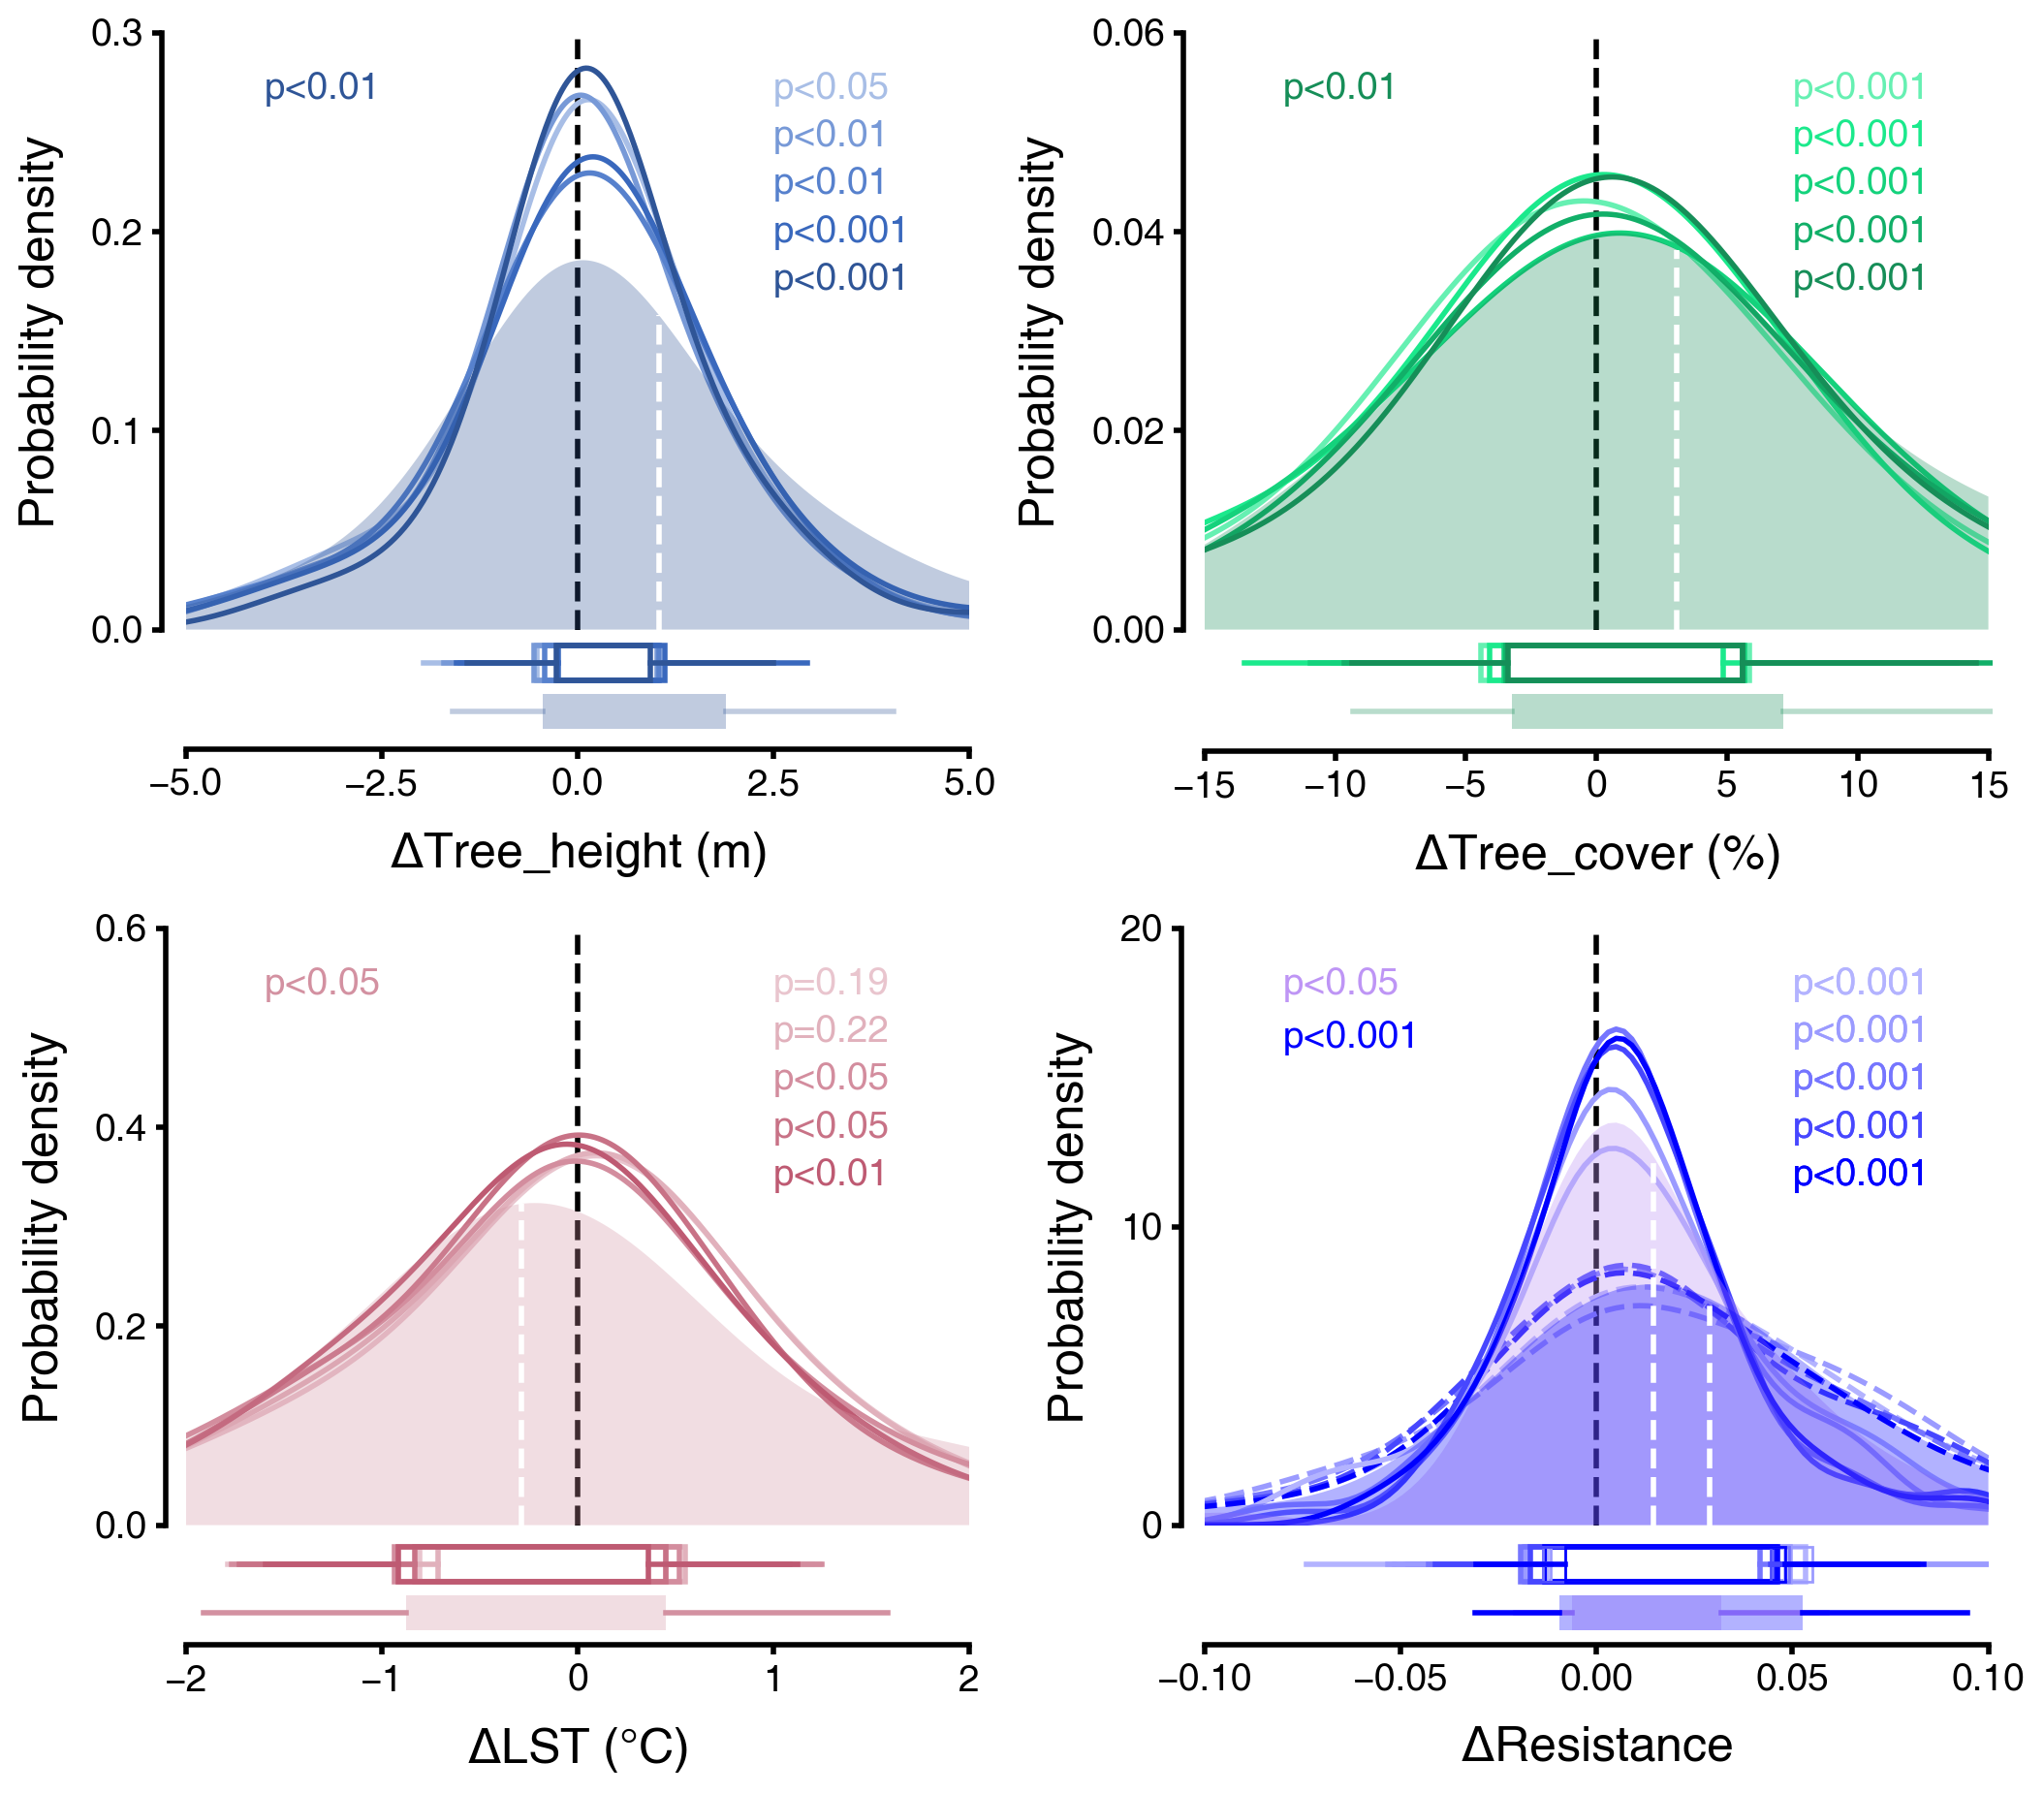

In [440]:
import gloce as gc
from scipy.stats import gaussian_kde
import matplotlib.colors as mcolors
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

fig = plt.figure(figsize=(12,10)) ##width, height default(8,6)
plt.subplots_adjust(wspace=0.3,hspace=0.5)
font = {'family': 'sans-serif',
        'sans-serif': 'Helvetica',
        'weight': 'normal',
        'size': 18}
plt.rc('font', **font)  # pass in the font dict as kwargs
cl1 = np.array([(47,85,151)])#color TH
cl2 = np.array([(22,142,88)])#color TC
cl_veg=[cl1/255,cl2/255]
cl3= np.array([(211,145,161)])#color LST
cl_lst=[cl3/255]
cl4= np.array([(0,0,255)])#color resistance
cl5= np.array([(190,149,245)])#color resistance
cl_res = [cl5/255,cl4/255]#color resistance_NDVI
cl=[cl1/255,cl2/255,cl3/255,cl4/255,cl5/255]

cl_th = np.array([(168,190,230),(119,153,215),(87,129,205),(57,104,189),(47,85,151)])#颜色由浅入
cl_tc = np.array([(102,240,178),(27,233,140),(20,210,124),(17,175,104),(22,142,88)])#,(146,208,80)
cl_veg1=[cl_th/255,cl_tc/255]

cl1 = np.array([(233,197,206),(225,177,188),(211,141,158),(200,114,134),(190,90,114)])#颜色由浅入深
cl_lst1=cl1/255

cl1 = np.array([(179,179,255),(155,155,255),(117,117,255),(71,71,255),(0,0,255)])#颜色由浅入
cl_res1=cl1/255

for i in range(4):
    ax = fig.add_subplot(2,2,i+1)
    ax.set_ylabel('Probability density',labelpad=10)
    #-----------vegetation structure----------------
    if i<2:
        x=np.linspace(-15,15,1000)
        mean=np.nanmean(data_test1[i])
        delta_rav=gc.nanravel(data_test1[i])
        kenal=gaussian_kde(delta_rav)
        z=kenal.evaluate(x)
        z_mean=kenal.evaluate(mean)
        ax.plot(x,z,lw=0.5,color='none')#,label=label[i]
        ax.fill_between(x,0,z,facecolor=cl[i],alpha=0.3,zorder=10)
        ax.vlines(mean,0,z_mean,lw=2,ls='--',color='white',zorder=11)
        if p_value_test1[i]<0.001:
            ax.text(0.1,0.89, 'p<0.001', fontsize=14,transform = ax.transAxes,color=cl[i])
        elif p_value_test1[i]<0.01:
            ax.text(0.1,0.89, 'p<0.01', fontsize=14,transform = ax.transAxes,color=cl[i])
        elif p_value_test1[i]<0.05:
            ax.text(0.1,0.89, 'p<0.05', fontsize=14,transform = ax.transAxes,color=cl[i])
        else:
            ax.text(0.1,0.89, 'p={:.2f}'.format(p_value_test1[i]), fontsize=14,transform = ax.transAxes,color=cl[i])
        if i ==0:
            ax.vlines(0,0,0.3,lw=2,ls='--',color='black')
            ax.set_ylim(0,0.3)
            ax.set_yticks(np.arange(0,0.31,0.1))
            ax.set_xlim(-5,5)
            ax.set_xticks(np.arange(-5,5.1,2.5))
            ax=plt.gca()
            ax.yaxis.set_ticks_position('left')
            ax.spines['left'].set_position(('data',-5.3))
            ax.xaxis.set_ticks_position('bottom')
            ax.spines['bottom'].set_position(('data',-0.06))
            ax.set_xlabel('$\Delta$Tree_height (m)',labelpad=10)
        else:
            ax.vlines(0,0,0.06,lw=2,ls='--',color='black')
            ax.set_ylim(0,0.06)
            ax.set_yticks(np.arange(0,0.061,0.02))
            ax.set_xlim(-15,15)
            ax.set_xticks(np.arange(-15,15.1,5))
            ax=plt.gca()
            ax.yaxis.set_ticks_position('left')
            ax.spines['left'].set_position(('data',-15.8))
            ax.xaxis.set_ticks_position('bottom')
            ax.spines['bottom'].set_position(('data',-0.0122))
            ax.set_xlabel('$\Delta$Tree_cover (%)',labelpad=10)
        #ax.legend(fontsize=14,loc='upper left',frameon=False,handlelength=1)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.xaxis.label.set_size(18)
        ax.xaxis.set_tick_params(width=2)
        ax.tick_params(labelsize=14)
        ax.yaxis.label.set_size(18)
        ax.yaxis.set_tick_params(width=2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        for j in range(5):
            x=np.linspace(-15,15,1000)
            mean=np.nanmean(data_test2[i][j])
            delta_rav=gc.nanravel(data_test2[i][j])
            kenal=gaussian_kde(delta_rav)
            z=kenal.evaluate(x)
            z_mean=kenal.evaluate(mean)
            ax.plot(x,z,lw=2,color=cl_veg1[i][j])#,label=label[i]
            #ax.vlines(mean,0,z_mean,lw=0.5,ls='-',color=cl_veg1[i][j])
            if p_test2[i][j]<0.001:
                #ax.text(0.73,0.89-j*0.09, '{:.2f} ***'.format(mean), fontsize=16,transform = ax.transAxes,color=cl[i][j])
                ax.text(0.75,0.89-j*0.08, 'p<0.001', fontsize=14,transform = ax.transAxes,color=cl_veg1[i][j])
            elif p_test2[i][j]<0.01:
                ax.text(0.75,0.89-j*0.08, 'p<0.01', fontsize=14,transform = ax.transAxes,color=cl_veg1[i][j])
            elif p_test2[i][j]<0.05:
                ax.text(0.75,0.89-j*0.08, 'p<0.05', fontsize=14,transform = ax.transAxes,color=cl_veg1[i][j])
            else:
                ax.text(0.75,0.89-j*0.08, 'p={:.2f}'.format(p_test2[i][j]), fontsize=14,transform = ax.transAxes,color=cl_veg1[i][j])        
        #添加箱线图
        if i ==0:
            ax1=fig.add_axes([0.124,0.5,0.34,0.06])#左，底，宽，高
            ax1.set_xlim(-5,5)
            ax1.set_xticks(np.arange(-5,5,2.5))
            ax1.axis('off')
            ax2=fig.add_axes([0.124,0.525,0.34,0.06])
            ax2.set_xlim(-5,5)
            ax2.set_xticks(np.arange(-5,5,2.5))
            ax2.axis('off')
        else:
            ax1=fig.add_axes([0.562,0.5,0.34,0.06])#左，底，宽，高
            ax1.set_xlim(-15,15)
            ax1.set_xticks(np.arange(-15,15,5))
            ax1.axis('off')
            ax2=fig.add_axes([0.562,0.525,0.34,0.06])
            ax2.set_xlim(-15,15)
            ax2.set_xticks(np.arange(-15,15,5))
            ax2.axis('off')
        bplot=ax1.boxplot(data_test1[i],
                          vert=False,
                          whis=(10,90),                
                          widths=0.3,
                          patch_artist=True,
                          showmeans=False,
                          meanprops = {'marker':'o','markerfacecolor':cl[i],"markeredgecolor":cl[i],"markersize":15,"alpha":0}, # 设置均值点的属性，点的形状、填充色
                          medianprops={'linewidth':'0.5',"color":cl[i],"alpha":0},
                          boxprops={"facecolor": cl[i], "edgecolor": 'none',"linewidth":2,"alpha":0.3},
                          capprops=None,
                          whiskerprops={'linewidth':'2','color':cl[i],"alpha":0.3},
                          showcaps=False,# 是否显示箱线图顶端和末端的两条线，默认显示；
                          showfliers = False,
                          flierprops = {'marker':'+','markersize':'3','markeredgecolor':cl[i],'color':cl[i]})

        for j in range(5):
            bplot1=ax2.boxplot(data_test2[i][j],
                          vert=False,
                          whis=(10,90),
                          widths=0.3,
                          patch_artist=True,
                          showmeans=False,
                          meanprops = {'marker':'o','markerfacecolor':cl_veg1[i][j],"markeredgecolor":cl_veg1[i][j],"markersize":15,"alpha":0}, # 设置均值点的属性，点的形状、填充色
                          medianprops={'linewidth':'0.5',"color":cl_veg1[i][j],"alpha":0},
                          boxprops={"facecolor": 'none', "edgecolor": cl_veg1[i][j],"linewidth":2,"alpha":1},
                          capprops=None,
                          whiskerprops={'linewidth':'2','color':cl_veg1[i][j]},
                          showcaps=False,# 是否显示箱线图顶端和末端的两条线，默认显示；
                          showfliers = False,
                          flierprops = {'marker':'+','markersize':'3','markeredgecolor':cl_veg1[i][j],'color':cl_veg1[i][j]})
    #-----------LST----------------
    elif i==2:
        x=np.linspace(-2,2,1000)
        mean=np.nanmean(data_test1[i])
        delta_rav=gc.nanravel(data_test1[i])
        kenal=gaussian_kde(delta_rav)
        z=kenal.evaluate(x)
        z_mean=kenal.evaluate(mean)
        print(mean,z_mean)
        ax.plot(x,z,lw=0.5,color='none')#,label=label
        ax.fill_between(x,0,z,facecolor=cl[i],alpha=0.3,zorder=10)
        ax.vlines(mean,0,z_mean,lw=2,ls='--',color='white',zorder=11)
        ax.vlines(0,0,0.6,lw=2,ls='--',color='black')
        if p_value_test1[i]<0.001:
            ax.text(0.1,0.89, 'p<0.001', fontsize=14,transform = ax.transAxes,color=cl[i])
        elif p_value_test1[i]<0.01:
            ax.text(0.1,0.89, 'p<0.01', fontsize=14,transform = ax.transAxes,color=cl[i])
        elif p_value_test1[i]<0.05:
            ax.text(0.1,0.89, 'p<0.05', fontsize=14,transform = ax.transAxes,color=cl[i])
        else:
            ax.text(0.1,0.89, 'p={:.2f}'.format(p_value_test1[i]), fontsize=14,transform = ax.transAxes,color=cl[i])
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_xlabel('$\Delta$LST (°C)',labelpad=10)

        ax=plt.gca()
        ax.yaxis.set_ticks_position('left')
        ax.spines['left'].set_position(('data',-2.1))
        ax.xaxis.set_ticks_position('bottom')
        ax.spines['bottom'].set_position(('data',-0.12))
        ax.set_ylim(0,0.6)
        ax.set_xlim(-2,2)
        ax.set_xticks(np.arange(-2,2.01,1))
        ax.set_yticks(np.arange(0,0.601,0.2))

        ax.tick_params(labelsize=14)
        ax.xaxis.label.set_size(18)
        ax.yaxis.label.set_size(18)
        ax.xaxis.set_tick_params(width=2)
        ax.yaxis.set_tick_params(width=2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        for j in range(5):
            x=np.linspace(-2,2,1000)
            mean=np.nanmean(data_test2[i][j])
            delta_rav=gc.nanravel(data_test2[i][j])
            kenal=gaussian_kde(delta_rav)
            z=kenal.evaluate(x)
            z_mean=kenal.evaluate(mean)
            ax.plot(x,z,lw=2,color=cl_lst1[j])#,label=label[i]
            #ax.vlines(mean,0,z_mean,lw=0.5,ls='-',color=cl_lst1[j])
            if p_test2[i][j]<0.001:
                #ax.text(0.73,0.89-j*0.09, '{:.2f} ***'.format(mean), fontsize=16,transform = ax.transAxes,color=cl[i][j])
                ax.text(0.75,0.89-j*0.08, 'p<0.001', fontsize=14,transform = ax.transAxes,color=cl_lst1[j])
            elif p_test2[i][j]<0.01:
                ax.text(0.75,0.89-j*0.08, 'p<0.01', fontsize=14,transform = ax.transAxes,color=cl_lst1[j])
            elif p_test2[i][j]<0.05:
                ax.text(0.75,0.89-j*0.08, 'p<0.05', fontsize=14,transform = ax.transAxes,color=cl_lst1[j])
            else:
                ax.text(0.75,0.89-j*0.08, 'p={:.2f}'.format(p_test2[i][j]), fontsize=14,transform = ax.transAxes,color=cl_lst1[j])  
        #添加箱线图----------------------------
        ax1=fig.add_axes([0.124,0.035,0.34,0.06])#左，底，宽，高
        ax1.set_xlim(-2,2)
        ax1.set_xticks(np.arange(-2,2.01,1))
        ax1.axis('off')
        bplot=ax1.boxplot(data_test1[i],
                          vert=False,
                          whis=(10,90),                
                          widths=0.3,
                          patch_artist=True,
                          showmeans=False,
                          meanprops = {'marker':'o','markerfacecolor':cl[i],"markeredgecolor":cl[i],"markersize":15,"alpha":0}, # 设置均值点的属性，点的形状、填充色
                          medianprops={'linewidth':'0.5',"color":cl[i],"alpha":0},
                          boxprops={"facecolor": cl[i], "edgecolor": 'none',"linewidth":2,"alpha":0.3},
                          capprops=None,
                          whiskerprops={'linewidth':'2','color':cl[i]},
                          showcaps=False,# 是否显示箱线图顶端和末端的两条线，默认显示;
                          showfliers = False,
                          flierprops = {'marker':'+','markersize':'3','markeredgecolor':cl[i],'color':cl[i]})
        for j in range(5):
            ax2=fig.add_axes([0.124,0.06,0.34,0.06])
            ax2.set_xlim(-2,2)
            ax2.set_xticks(np.arange(-2,2,1))
            ax2.axis('off')
            bplot=ax2.boxplot(data_test2[i][j],
                              vert=False,
                              whis=(10,90),                
                              widths=0.3,
                              patch_artist=True,
                              showmeans=False,
                              meanprops = {'marker':'o','markerfacecolor':cl_lst1[j],"markeredgecolor":cl_lst1[j],"markersize":15,"alpha":0}, # 设置均值点的属性，点的形状、填充色
                              medianprops={'linewidth':'0.5',"color":cl_lst1[j],"alpha":0},
                              boxprops={"facecolor": 'none', "edgecolor": cl_lst1[j],"linewidth":2,"alpha":1},
                              capprops=None,
                              whiskerprops={'linewidth':'2','color':cl_lst1[j]},
                              showcaps=False,# 是否显示箱线图顶端和末端的两条线，默认显示；
                              showfliers = False,
                              flierprops = {'marker':'+','markersize':'3','markeredgecolor':cl_lst1[j],'color':cl_lst1[j]})
    elif i==3:
        x=np.linspace(-0.1,0.1,100)
        ax.vlines(0,0,20,lw=2,ls='--',color='black')
        ax.set_ylim(0,20)
        ax.set_yticks(np.arange(0,20.1,10))
        ax.set_xlim(-0.1,0.1)
        ax.set_xticks(np.arange(-0.1,0.101,0.05))
        ax.set_xlabel('$\Delta$Resistance',labelpad=10)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax=plt.gca()
        ax.yaxis.set_ticks_position('left')
        ax.spines['left'].set_position(('data',-0.106))
        ax.xaxis.set_ticks_position('bottom')
        ax.spines['bottom'].set_position(('data',-4))
        ax.tick_params(labelsize=14)
        ax.xaxis.label.set_size(18)
        ax.yaxis.label.set_size(18)
        ax.xaxis.set_tick_params(width=2)
        ax.yaxis.set_tick_params(width=2)
        ax.spines['left'].set_linewidth(2)
        ax.spines['bottom'].set_linewidth(2)
        for j in range(2):
            mean=np.nanmean(data_test1[i][j])
            delta_rav=gc.nanravel(data_test1[i][j])
            kenal=gaussian_kde(delta_rav)
            z=kenal.evaluate(x)
            z_mean=kenal.evaluate(mean)
            print(mean,z_mean)
            ax.plot(x,z,lw=0.5,color='none')
            if j ==0:
                ap=0.35
            else:
                ap=0.3
            ax.fill_between(x,0,z,facecolor=cl_res[j],alpha=ap,zorder=10)
            ax.vlines(mean,0,z_mean,lw=2,ls='--',color='white',zorder=11)
            if p_value_test1[i][j]<0.001:
                ax.text(0.1,0.80, "p<0.001", fontsize=14,transform = ax.transAxes,color=cl_res[j])
                #ax.text(-0.02,0.80, "$\Delta$Resistance_SIF", fontsize=14,transform = ax.transAxes,color=cl_res[j])
            elif p_value_test1[i][j]<0.05:
                ax.text(0.1,0.89, "p<0.05", fontsize=14,transform = ax.transAxes,color=cl_res[j])
                #ax.text(-0.02,0.89, "$\Delta$Resistance_NDVI", fontsize=14,transform = ax.transAxes,color=cl_res[j])
            ax1=fig.add_axes([0.56,0.035,0.34,0.06])#左，底，宽，高
            ax1.set_xlim(-0.1,0.1)
            ax1.set_xticks(np.arange(-0.1,0.101,0.05))
            ax1.axis('off')
            bplot=ax1.boxplot(data_test1[i][j],
                              vert=False,
                              whis=(10,90),                
                              widths=0.3,
                              patch_artist=True,
                              showmeans=True,
                              meanline=True,
                              meanprops = {"color":cl_res[j],"linewidth":'2',"linestyle":'-',"alpha":0}, # 设置均值点的属性，点的形状、填充色
                              medianprops={'linewidth':'0.5',"color":cl_res[j],"alpha":0},
                              boxprops={"facecolor": cl_res[j], "edgecolor": 'none',"linewidth":2,"alpha":0.3},
                              capprops=None,
                              whiskerprops={'linewidth':'2','color':cl_res[j]},
                              showcaps=False,# 是否显示箱线图顶端和末端的两条线，默认显示；
                              showfliers = False,
                              flierprops = {'marker':'+','markersize':'3','markeredgecolor':cl_res[j],'color':cl_res[j]})
        for n in range(5):
            #---------res_ndvi PDF----------------
            x=np.linspace(-1,1,1000)
            mean=np.nanmean(data_test2[3][n])
            delta_rav=gc.nanravel(data_test2[3][n])
            kenal=gaussian_kde(delta_rav)
            z=kenal.evaluate(x)
            z_mean=kenal.evaluate(mean)
            ax.plot(x,z,lw=2,color=cl_res1[n],zorder=6)#,label=label[i]
            #ax.vlines(mean,0,z_mean,lw=0.5,ls='-',color=cl_res1[n])
            if p_test2[3][n]<0.001:
                #ax.text(0.73,0.89-j*0.09, '{:.2f} ***'.format(mean), fontsize=16,transform = ax.transAxes,color=cl[i][j])
                ax.text(0.75,0.89-n*0.08, 'p<0.001', fontsize=14,transform = ax.transAxes,color=cl_res1[n])
            elif p_test2[3][n]<0.01:
                ax.text(0.75,0.89-n*0.08, 'p<0.01', fontsize=14,transform = ax.transAxes,color=cl_res1[n])
            elif p_test2[3][n]<0.05:
                ax.text(0.75,0.89-n*0.08, 'p<0.05', fontsize=14,transform = ax.transAxes,color=cl_res1[n])
            else:
                ax.text(0.75,0.89-n*0.08, 'p={:.2f}'.format(p_test2[3][n]), fontsize=14,transform = ax.transAxes,color=cl_res1[n]) 
            ax2=fig.add_axes([0.56,0.06,0.34,0.06])#左，底，宽，高
            ax2.set_xlim(-0.05,0.05)
            ax2.set_xticks(np.arange(-0.05,0.0501,0.05))
            ax2.axis('off')
            bplot=ax2.boxplot(data_test2[3][n],
                              vert=False,
                              whis=(10,90),              
                              widths=0.3,
                              patch_artist=True,
                              showmeans=False,
                              meanprops = {'marker':'o','markerfacecolor':cl_res1[n],"markeredgecolor":cl_res1[n],"markersize":15,"alpha":0}, # 设置均值点的属性，点的形状、填充色
                              medianprops={'linewidth':'0.5',"color":cl_res1[n],"alpha":0},
                              boxprops={"facecolor": 'none', "edgecolor": cl_res1[n],"linewidth":2,"alpha":1},
                              capprops=None,
                              whiskerprops={'linewidth':'2','color':cl_res1[n]},
                              showcaps=False,# 是否显示箱线图顶端和末端的两条线，默认显示；
                              showfliers = False,
                              flierprops = {'marker':'+','markersize':'3','markeredgecolor':cl_res1[n],'color':cl_res1[n]})
        for n in range(5):
            x=np.linspace(-1,1,1000)
            mean1=np.nanmean(data_test2[4][n])
            delta_rav=gc.nanravel(data_test2[4][n])
            kenal=gaussian_kde(delta_rav)
            z=kenal.evaluate(x)
            z_mean=kenal.evaluate(mean1)
            ax.plot(x,z,lw=2,ls='--',color=cl_res1[n],zorder=5)#,label=label[i]
            #ax.vlines(mean1,0,z_mean,lw=0.5,ls='--',color=cl_res1[n])
            if p_test2[4][n]<0.001:
                #ax.text(0.73,0.89-j*0.09, '{:.2f} ***'.format(mean), fontsize=16,transform = ax.transAxes,color=cl[i][j])
                ax.text(0.75,0.89-n*0.08, 'p<0.001', fontsize=14,transform = ax.transAxes,color=cl_res1[n])
            elif p_test2[4][n]<0.01:
                ax.text(0.75,0.89-n*0.08, 'p<0.01', fontsize=14,transform = ax.transAxes,color=cl_res1[n])
            elif p_test2[4][n]<0.05:
                ax.text(0.75,0.89-n*0.08, 'p<0.05', fontsize=14,transform = ax.transAxes,color=cl_res1[n])
            else:
                ax.text(0.75,0.89-n*0.08, 'p={:.2f}'.format(p_test2[4][n]), fontsize=14,transform = ax.transAxes,color=cl_res1[n]) 
            ax3=fig.add_axes([0.56,0.06,0.34,0.06])#左，底，宽，高
            ax3.set_xlim(-0.1,0.1)
            ax3.set_xticks(np.arange(-0.1,0.101,0.05))
            ax3.axis('off')
            bplot=ax3.boxplot(data_test2[4][n],
                              vert=False,
                              whis=(10,90),              
                              widths=0.3,
                              patch_artist=True,
                              showmeans=False,
                              meanprops = {'marker':'o','markerfacecolor':cl_res1[n],"markeredgecolor":cl_res1[n],"markersize":15,"alpha":0}, # 设置均值点的属性，点的形状、填充色
                              medianprops={'linewidth':'0.5',"color":cl_res1[n],"alpha":0},
                              boxprops={"facecolor": 'none', "edgecolor": cl_res1[n],"linewidth":1,"linestyle":"--","alpha":1},
                              capprops=None,
                              whiskerprops={'linewidth':'2','color':cl_res1[n]},
                              showcaps=False,# 是否显示箱线图顶端和末端的两条线，默认显示；
                              showfliers = False,
                              flierprops = {'marker':'+','markersize':'3','markeredgecolor':cl_res1[n],'color':cl_res1[n]})